---
title: 'Cluster Analysis of Eigenfaces through Principal Component Analysis'
---

In [1]:
# Load core libraries and utilities
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.transform import resize
from sklearn.cluster import KMeans

# Pull in helper functions.  Not best practice, but we control the library
# so it's manageable.  
from math_540_image_analysis_helper_functions import *

# Jupyter notebook "magic"
%matplotlib inline

In [2]:
# Data Loader from kaggle.com 
import kagglehub
current_working_directory = os.getcwd()
data_path = kagglehub.dataset_download("olgabelitskaya/yale-face-database")
os.chdir(data_path)
# Remove redundant data directory after download which otherwise causes issues with the data loader.  
! rm -rf ./data
os.chdir(current_working_directory)

# Building Face Space

So we're embarking on a relatively peculiar idea.  Suppose I gave you a set of images stored as matrices.  We'll denote the set as $\left\{{\bf A}_{j}\right\}_{j=1}^{N_{d}}$ with the understanding that each matrix ${\bf A}_{j}$ is the same size (say $m\times n$).  Now, I'm going to *flatten* each matrix column-over column so that we transform the real value $m\times n$ matrix ${\bf A}_{j}$ into the $mn \times 1$ column ${\bf a}_{j}$ i.e. 
$$
{\bf a}_{j} = \text{flatten}({\bf A}_{j}), ~ {\bf a}_{j} \in \mathbb{R}^{mn}.
$$

From here, I am now going to put all of these columns together in one massive $mn \times N_{d}$ matrix, say ${\bf \bar{A}}$ so that 
$$
{\bf \bar{A}} = \left(\left.{\bf a}_{1}\right|\cdots \left|{\bf a}_{N_{d}}\right.\right)
$$
As in our analysis of a single image, we define the average across columns $\boldsymbol{\mu}$ so that 
$$
\boldsymbol{\mu} = \frac{1}{N_{d}}\sum_{j=1}^{N_{d}}{\bf a}_{j}, ~ \boldsymbol{\mu}\in \mathbb{R}^{mn}.
$$
Note, $\boldsymbol{\mu}$ is the "average" image.  Let's define the zero-average matrix ${\bf Y}$ so that 
$$
{\bf Y} = \left(\left.{\bf y}_{1}\right|\cdots \left|{\bf y}_{N_{d}} \right.\right), ~ {\bf y}_{j} = {\bf a}_{j}-\boldsymbol{\mu}.
$$

Now, at this point we need to introduce more statistics.  We define the $mn\times mn$ *variance* matrix $\mathbb{V}$ so that 
$$
\mathbb{V} = \frac{1}{N_{d}}\sum_{j=1}^{N_{d}} {\bf y}_{j}{\bf y}_{j}^{T}.
$$

*Problem*: Show that $\mathbb{V} = \frac{1}{N_{d}}{\bf Y}{\bf Y}^{T}$, and thus that $\mathbb{V}$ is a positve semi-definite matrix.

So by variance we can also think *standard deviation* which is to say, how much does any one image spread around the average?  This must be a matrix (tensor) since we have plural directions and the ability to vary independently along every other direction.  

Now we are going to ask what turns out to be a powerful question in data science.  Is there a direction (described by some unit vector ${\bf \hat{u}}_{1}$) along which the variance is maximized?  In more formal terms, we want to solve
$$
{\bf \hat{u}}_{1} = \text{arg max}_{{\bf \hat{u}}}\left<\mathbb{V}{\bf \hat{u}},{\bf \hat{u}}\right>
$$
Of course, since $\mathbb{V}$ is positive semi-defininte (or we can think of using the SVD of ${\bf Y}$), we can use the spectral decomposition of symmetric matrices theorem and write the diagonalization  
$$
\mathbb{V} = {\bf U}\boldsymbol{\tilde{\Sigma}}^{2}{\bf U}^{T},
$$
and since ${\bf U}$ is an orthogonal matrix, we preserve norms so that 
$$
\left|\left|{\bf U}^{T}{\bf \hat{u}}\right|\right|_{2} = \left|\left|{\bf \hat{u}}\right|\right|_{2} = 1.
$$
Thus, we can take the expression we wish to optimize and by introducing the variable transformation ${\bf \hat{z}} = {\bf U}^{T}{\bf \hat{u}}$ preserve the set over which we wish to optimize.  In turn, we then have   
$$
\left<\mathbb{V}{\bf \hat{u}},{\bf \hat{u}}\right> = \left<\boldsymbol{\tilde{\Sigma}}^{2}{\bf \hat{z}},{\bf \hat{z}}\right>, 
$$
so ultimately we can look for the solution to the simpler optimization problem 
$$
{\bf \hat{z}}_{1} = \text{arg max}_{{\bf \hat{z}}} \left<\boldsymbol{\tilde{\Sigma}}^{2}{\bf \hat{z}},{\bf \hat{z}}\right>,
$$
and then find the solution to our original problem through the identity
$$
{\bf \hat{u}}_{1} = {\bf U} {\bf \hat{z}}_{1}.
$$

Of course, this still leaves us with the task of finding an optimal ${\bf \hat{z}}$.  Following the convention we use for ordering singular values (which is really what we're talking about here anyway), we suppose the diagonal entries of $\boldsymbol{\tilde{\Sigma}}^{2}$, say $\tilde{\sigma}^{2}_{j}$, are ordered so that $\tilde{\sigma}_{1}\geq\cdots \geq \tilde{\sigma}_{r} > 0$, with $r = \text{rank}({\bf Y})$.   

*Problem*: Show that 
$$
\left<\boldsymbol{\tilde{\Sigma}}^{2}{\bf \hat{z}},{\bf \hat{z}}\right> = \sum_{j=1}^{r}\tilde{\sigma}^{2}_{j}\hat{z}_{j}^{2} \leq \tilde{\sigma}_{1}^{2}.
$$

What the above inequality now tells us is that 
$$
{\bf \hat{z}}_{1} = \left(1 ~0 \cdots 0\right)^{T},
$$
since then $\left<\boldsymbol{\tilde{\Sigma}}^{2}{\bf \hat{z}}_{1},{\bf \hat{z}}_{1}\right> = \tilde{\sigma}_{1}^{2}$, which as we just showed, the largest $\left<\boldsymbol{\tilde{\Sigma}}^{2}{\bf \hat{z}},{\bf \hat{z}}\right>$ can possibly be for any unit vector ${\bf \hat{z}}$.  Moreover, we also now see that 
$$
{\bf \hat{u}}_{1} = {\bf U} \left(1 ~0 \cdots 0\right)^{T},
$$
so that our optimal direction describing the maximum variance in our data is simply the first column of the matrix ${\bf U}$.  

Running with this argument, we now have a richer and more interesting intepretation of the SVD of the zero-average data matrix ${\bf Y}$ written as 
$$
{\bf Y} = {\bf U}\boldsymbol{\Sigma}{\bf V}^{T}.
$$

*Problem*: Show that $\boldsymbol{\tilde{\Sigma}}^{2} = \frac{1}{N_{d}}\boldsymbol{\Sigma}^{2}$.  

Now we see that the columns of ${\bf U}$, or the principal components, describe the directions along which the variance in the data is greatest, next greatest, etc... and down on to the least.  So by working in the coordinates of principal components, we are working a basis adapted to the variance of our data.  So, a collection of images can be used to *learn* which features across the family of images leads to the greatest variance and then encapsulate as a direction along a principal component.  We now use this to build *dictionaries* of principal components generated by studying collections of pictures of human faces.  

## Loading Data

In [3]:
# Load the images and labels into a list of images and a list of labels.

image_list, labels_list = file_builder(data_path)

indexed_labels = list(enumerate(labels_list))
sorted_indexed_labels = sorted(indexed_labels, key=lambda x: x[1])
swapped_indices = [sorted_indexed_labels[i][0] for i in range(len(sorted_indexed_labels))]

num_images = len(image_list)
row, col = np.shape(image_list[0])
image_mat = np.zeros((row*col, num_images), dtype=np.float64)

for cnt in range(num_images):
    image_mat[:, cnt] = image_list[swapped_indices[cnt]].flatten()

print(f"Total number of images is: {num_images}")
print(f"Pixel counts are {row} by {col}")


Total number of images is: 165
Pixel counts are 256 by 256


## Naive Training Sets

So to `learn' anything from data, we have to separate data so that we can use mathematical tools to build out inferential tools that need to then be tested for their applicability in untried situations.  Thus, if we have a $N_{d}$ number of faces, we are going to randomly select $N_{tr}$ of them to serve as our *training set* and then assess the quality of the tools that we build (in this case a collection of principal components) on the complimentary number of images in our *testing set*.  We denote the number of testing images as $N_{tst}$ and emphasize that 
$$
N_{tr} + N_{tst} = N_{d}.
$$

In the following code, we let $N_{tr} = .75 N_{d}$, where we emphasize again, we have selected the training set at random.  To build our dictionary of principal components, we now take our randomly selected set of faces, say $\left\{{\bf A}_{j}\right\}_{j=1}^{N_{tr}}$ and generate a matrix, say ${\bf Y}_{tr}$ following the procedure outlined at the beginning of this notebook.  From this, we generate our usual (economy) SVD with 
$$
{\bf Y}_{tr} = {\bf U}_{r}\boldsymbol{\Sigma}_{r}{\bf V}_{r}^{T}, ~ r = \text{rank}({\bf Y}_{tr}).
$$

From here, we introduce a threshhold parameter, say $r_{sl}$, that selects what we think are the most important principal components (see the last module on image compression for motivation).  Scaling by the largest singular value $\sigma_{1}$, we only use those columns of ${\bf U}_{r}$ corresponding to singular values $\sigma_{j}$ such that 
$$
\log_{10}\left(\frac{\sigma_{j}}{\sigma_{1}}\right) \geq -r_{sl}.
$$
Thus, if we select $r_{sl}=2$, that means we only keep columns corresponding to singular values that are $1/100$ the size of $\sigma_{1}$.  

In [4]:
# Randomly select our training set and build the dictionary of principal components.  

percentage_training = .75
mode_selection_threshhold = 2.

num_train_images = int(np.floor(percentage_training * num_images))
train_indices = np.random.choice(np.arange(num_images), num_train_images, replace=False)
training_images = image_mat[:, train_indices]

test_images = np.delete(image_mat, train_indices, axis=1)
zero_avg_test, avg_test = zero_mean(test_images)

zero_avg_train, avg_train = zero_mean(training_images)
u_train, s_train = mode_builder(zero_avg_train)
u_red = mode_selector(u_train, s_train, mode_selection_threshhold)

print(f"Number of Training Images is: {num_train_images}")
print(f"Number of Selected Modes is: {u_red.shape[1]}")

Number of Training Images is: 123
Number of Selected Modes is: 118


Now we look at what happens when we take a test image and project it along our dictionary of principal components learned from our training data.  

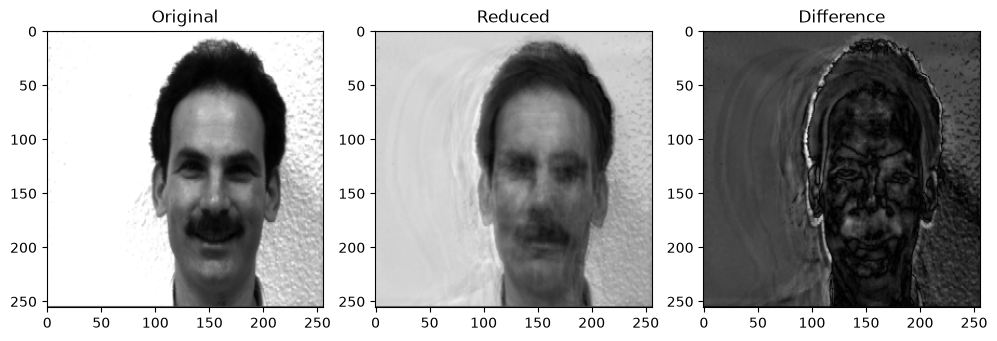

In [5]:
test_choice_ind = 0
test_image_approx = mode_projector(zero_avg_test, u_red)
test_image_approx += avg_test

test_true_mat = test_images[:, test_choice_ind].reshape(row, col)
test_approx_mat = test_image_approx[:, test_choice_ind].reshape(row, col)

image_comparison(test_true_mat, test_approx_mat)

Okay, not bad.  If we look at the result in the Reduced panel and compare it to the Original panel, we get something that vaguely resembles what we know the correct answer to be.  That said, looking at Difference, we see an enormous amount of detail gets lost, thereby of course explaining why our prediction (in Reduced) is so hazy. 

## Less Naive Decompositions Because We Took Some Time to Learn Our Data

Okay, but if we now a little more about our data, then we know that the data includes 11 photos of one person just from different angles, with different expressions, or using different lighting levels.  In the prior case, we just took a pile of images and built training sets at random with no regards to the obvioius structure our data otherwise posseses.  That's not a great idea, and we should explore now what happens if we put a little more thought into building dictionaries of principal components that better respect the obvious structure of our data.  

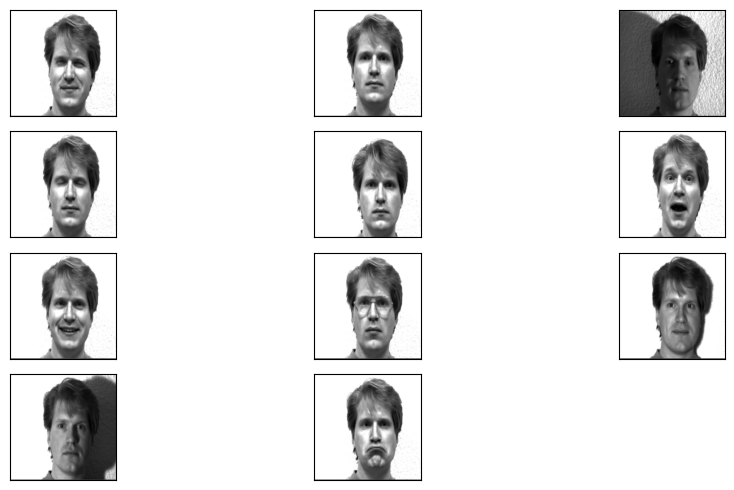

In [ ]:
# Let's look at the 11 images attributed to one person in the data.  

num_angles = 11
fig, axes = plt.subplots(4, 3, figsize=(10, 5))
ax = axes.ravel()
for jj in range(num_angles):
    ax[jj].imshow(image_mat[:, jj].reshape(row, col), cmap=plt.cm.gray)
    ax[jj].tick_params(
    axis='both',       # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off    
    left=False,        # ticks along the left edge are off
    labelbottom=False,
    labelleft=False
    ) 
for jj in range(11, 12):
    fig.delaxes(ax[jj])
fig.tight_layout()

In [ ]:
# Randomly select our training set (with more care of course) and build the dictionary of principal components.  

percentage_training = .75
mode_selection_threshhold = 2.

num_distinct_people = int(num_images/num_angles)
num_train_people = int(np.floor(percentage_training * num_distinct_people))
train_people = np.random.choice(np.arange(num_distinct_people), num_train_people, replace=False)

train_indices = np.zeros(num_train_people*num_angles, dtype=int)
for ll in range(num_train_people):
    train_indices[ll*num_angles:num_angles*(ll+1)] = np.arange(train_people[ll]*num_angles,(train_people[ll]+1)*num_angles)
training_images = image_mat[:, np.sort(train_indices)]

testing_images = np.delete(image_mat, train_indices, axis=1)
zero_avg_test, avg_test = zero_mean(test_images)

zero_avg_train, avg_train = zero_mean(training_images)
u_train, s_train = mode_builder(zero_avg_train)
u_red = mode_selector(u_train, s_train, mode_selection_threshhold)

print(f"Number of Distinct People is: {num_distinct_people}")
print(f"Number of Distinct Training People is: {num_train_people}")
print(f"Number of Training Images is: {training_images.shape[1]}")
print(f"Number of Selected Modes is: {u_red.shape[1]}")

Number of Distinct People is: 15
Number of Distinct Training People is: 11
Number of Training Images is: 121
Number of Selected Modes is: 111


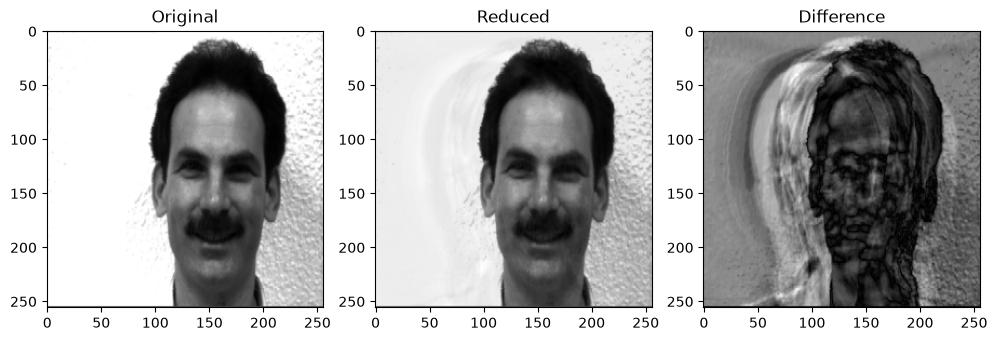

In [ ]:
# Look at a test case now that we've taken the structure of the data into account. 

test_choice_ind = 0
test_image_approx = mode_projector(zero_avg_test, u_red)
test_image_approx += avg_test

test_true_mat = test_images[:, test_choice_ind].reshape(row, col)
test_approx_mat = test_image_approx[:, test_choice_ind].reshape(row, col)

image_comparison(test_true_mat, test_approx_mat)

As we can plainly see, the quality of our projection via our learned dictionary of principal components is vastly greater than we paid no attention to the structure of the data.  

## Projecting Beans

There are limits here though to the ability to use dictionaries of faces to analyze arbitrary images.  Let's see what our learned dictionary does to poor Beans.  

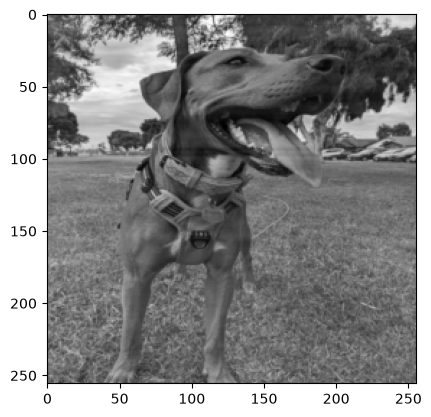

In [9]:
beanie = io.imread('beans.jpg', as_gray=True)
small_beans = resize(beanie, (row, col), anti_aliasing=True)
zero_avg_beans, beans_avg = zero_mean(small_beans)
plt.imshow(zero_avg_beans, cmap=plt.cm.gray)

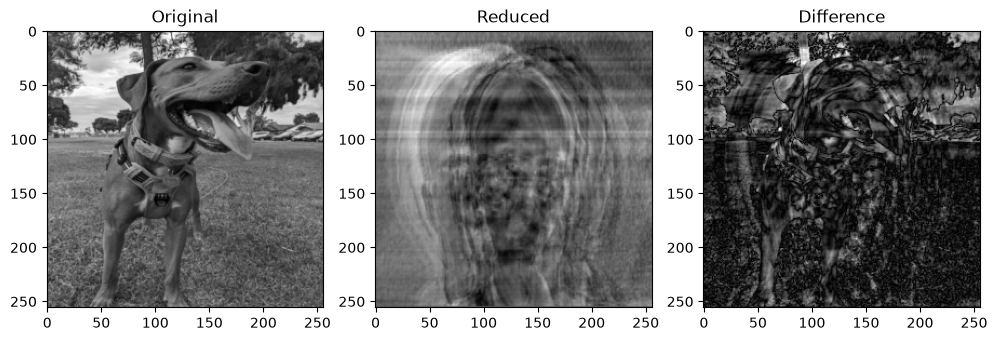

In [10]:
respanned_beans = mode_projector(zero_avg_beans.flatten(), u_red)
rebuilt_beans = respanned_beans.reshape(row, col) + beans_avg
image_comparison(small_beans, rebuilt_beans)

Yeah, so turns out Beans is not a human face.  And while that's obvious, this also shows us the limits of using particular classes of data in learning tasks.  While our approach outlined above is by no means the final word in image classification, it does encapsulate all of the fundamental problems and appraoches one finds as one moves to using more powerful methods.  

## K-Means Clustering and Type Identification

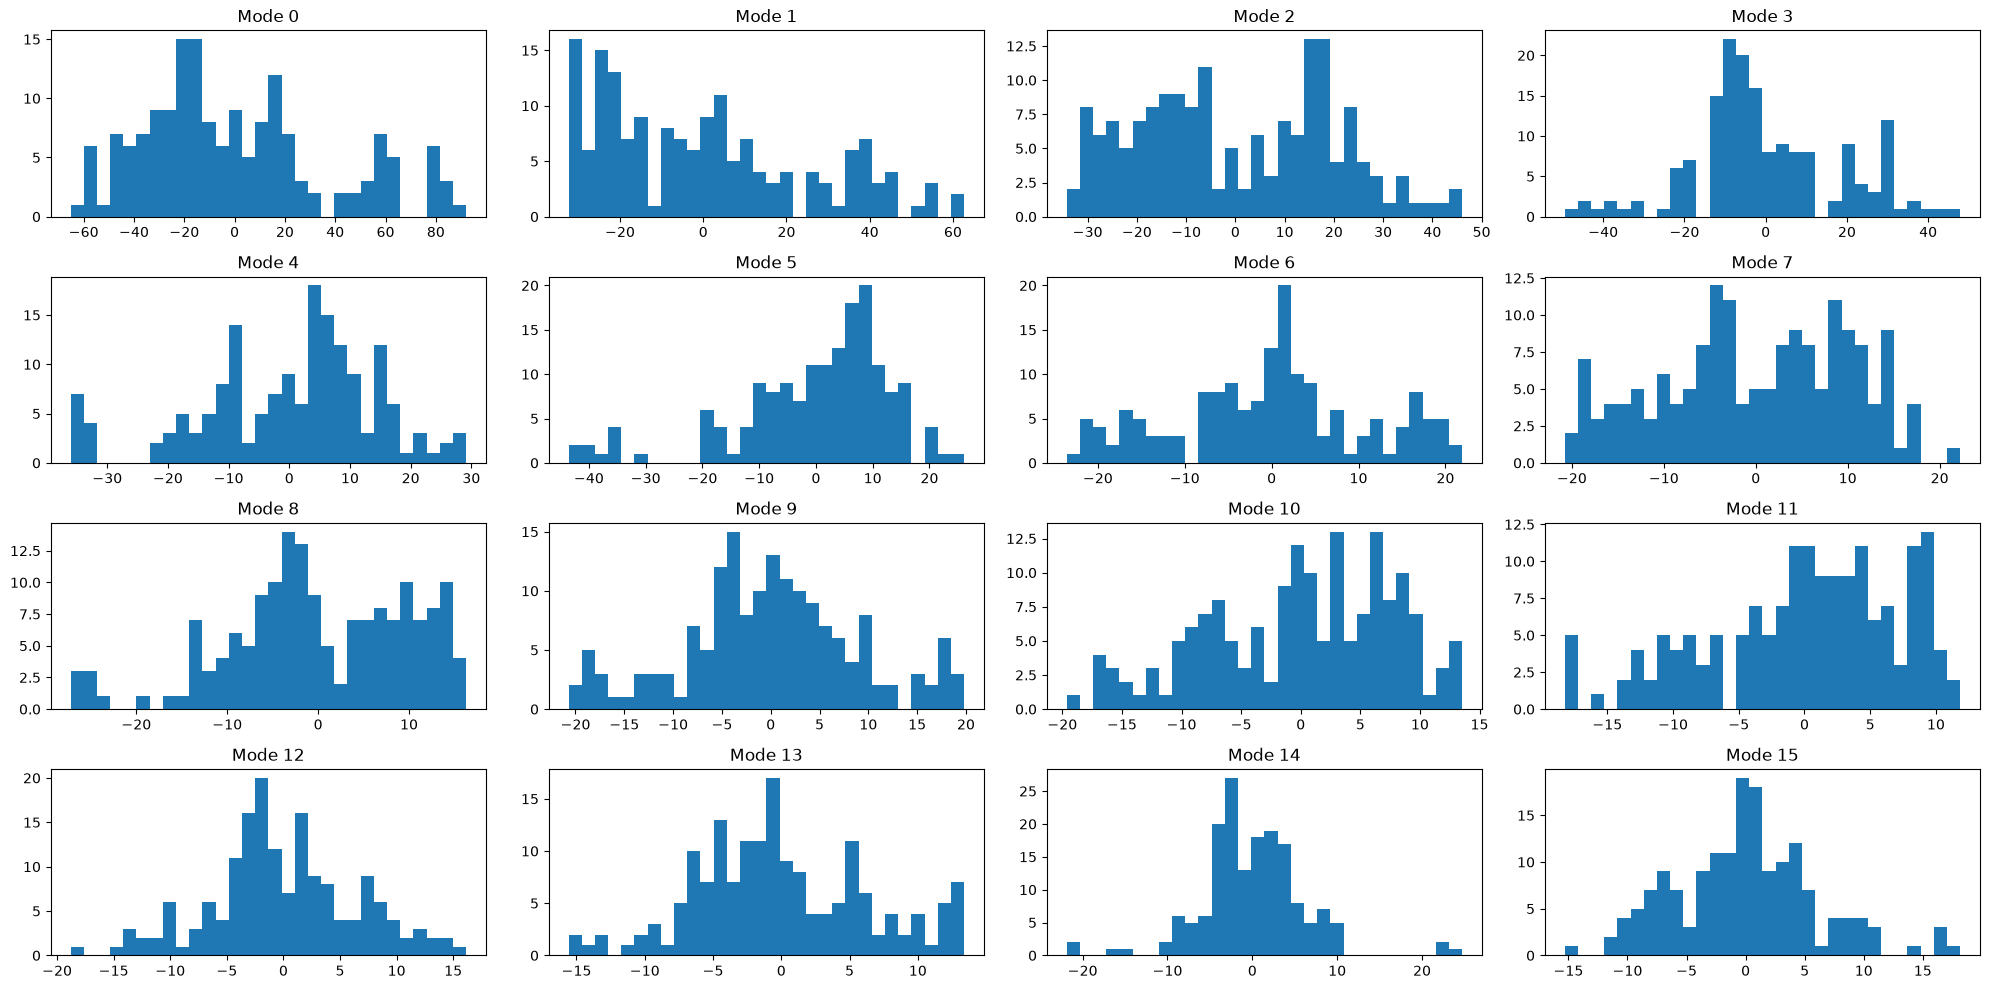

In [15]:
zero_avg_crp, avg_crp = zero_mean(image_mat)
u_crp, s_crp = mode_builder(zero_avg_crp)
u_crp_red = mode_selector(u_crp, s_crp, 1.)

projected_images = u_crp_red.T @ zero_avg_crp
num_modes = u_crp_red.shape[1]

fig, axes = plt.subplots(4, 4, figsize=(20, 10))
ax = axes.ravel()
num_bins = 30
for jj in range(16):
  ax[jj].hist(projected_images[jj, :], bins=num_bins)
  ax[jj].set_title(f"Mode {jj}")
plt.tight_layout()


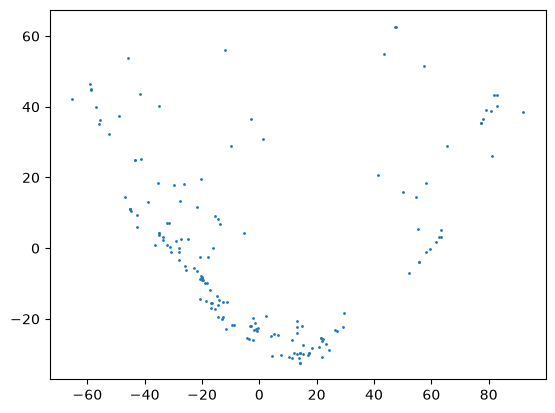

In [16]:
plt.scatter(projected_images[0, :], projected_images[1, :], s=1.)

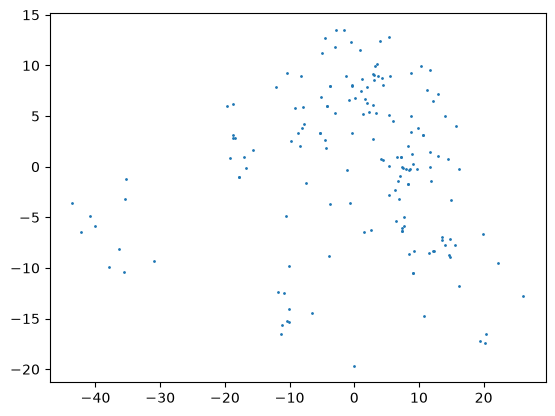

In [17]:
plt.scatter(projected_images[5, :], projected_images[10, :], s=1.)

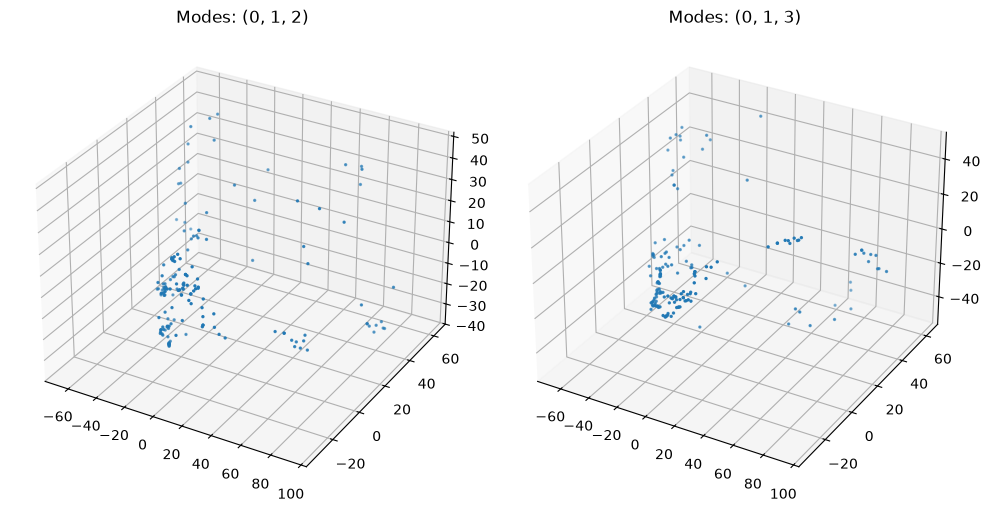

In [18]:
comb_list = [[0, 1, 2], [0, 1, 3]] # add your particular choices here

fig = plt.figure(figsize=(10, 5))
for jj in range(len(comb_list)):
  x = projected_images[comb_list[jj][0], :]
  y = projected_images[comb_list[jj][1], :]
  z = projected_images[comb_list[jj][2], :]
  ax = fig.add_subplot(1, len(comb_list), jj+1, projection='3d') # you might need to adjust this depending on how many images you want to plot at once
  ax.scatter(x, y, z, s=2.)
  ax.set_title(f"Modes: ({comb_list[jj][0]}, {comb_list[jj][1]}, {comb_list[jj][2]})")

plt.tight_layout()

(2, 165)


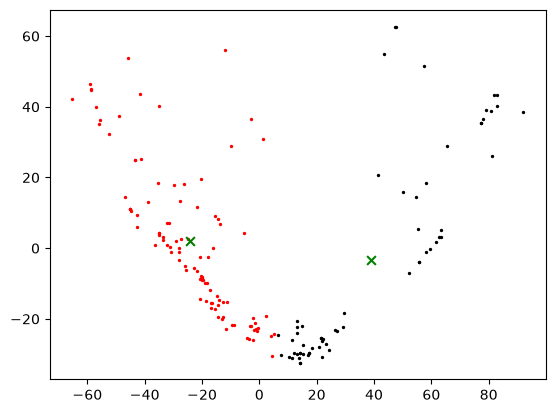

In [19]:
cluster_data = np.array([projected_images[0, :], projected_images[1, :]])
print(cluster_data.shape)
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(cluster_data.T)
labels = kmeans.labels_
centers = kmeans.cluster_centers_

group_one = labels == 1
group_two = labels == 0
cluster_one = cluster_data[:,group_one]
cluster_two = cluster_data[:, group_two]

plt.scatter(cluster_one[0, :], cluster_one[1, :], s=2., c='r')
plt.scatter(cluster_two[0, :], cluster_two[1, :], s=2., c='k')
plt.scatter(centers[:, 0], centers[:, 1], s=40., c='g', marker='x')